# Univariate Time Series Models I
**HS 821 · Lecture 5 · Topics in Time Series Econometrics**

**Sunil Paul**

August 2026 · R 4.6

The statistics reviewed in the preceding lectures treated observations largely as a random sample. Time-series data are different: **ordering matters**, observations may be dependent, and in most applications we observe only **one realization** of an underlying stochastic process.

This lecture develops the probabilistic foundation needed for ARMA modelling and forecasting.

### Learning objectives

- distinguish a stochastic process from an observed realization;
- interpret the mean, autocovariance, and autocorrelation functions;
- distinguish stationarity from ergodicity (time average vs. ensemble average);
- explain white noise and the role of innovations;
- use the Wold representation and lag-operator notation;
- derive the ACF of MA processes and explain invertibility.



## From random samples to time series

A **stochastic process** is a collection of random variables indexed by time,

$$
\{Y_t:t\in\mathbb Z\}.
$$

Before observation, each $Y_t$ is a random variable. Once the process is observed over $t=1,\ldots,T$, we obtain one **realization**,

$$
y_1,y_2,\ldots,y_T.
$$

The distinction matters because a time series is not merely an unordered collection of observations. Its **temporal ordering and dependence structure** are part of the object being studied.

### Think before proceeding

Suppose you randomly shuffle the observations in a cross-sectional dataset. Much of the statistical information is unchanged.

What would happen if you randomly shuffled a time series?

The marginal distribution might remain unchanged, but its temporal dependence—and therefore its time-series structure—could be destroyed.


## Moments of a stochastic process

The **mean function** is

$$
\mu_t=E(Y_t).
$$

The covariance between observations $h$ periods apart is

$$
\gamma(t,t-h)
=
\operatorname{Cov}(Y_t,Y_{t-h})
=
E[(Y_t-\mu_t)(Y_{t-h}-\mu_{t-h})].
$$

The corresponding correlation is

$$
\rho(t,t-h)
=
\frac{\gamma(t,t-h)}
{\sqrt{\operatorname{Var}(Y_t)\operatorname{Var}(Y_{t-h})}}.
$$

For a covariance-stationary process these depend only on the **lag** $h$:

$$
\gamma_h=\operatorname{Cov}(Y_t,Y_{t-h}),
\qquad
\rho_h=\frac{\gamma_h}{\gamma_0}.
$$

The sequence $\{\rho_h\}$ is the **autocorrelation function (ACF)**, and its plot against $h$ is the **correlogram**.


### Restrictions on an autocovariance function

For a covariance-stationary process,

$$
\gamma_h=\gamma_{-h},
\qquad
\rho_h=\rho_{-h},
$$

$$
\gamma_0=\operatorname{Var}(Y_t)\ge0,
\qquad
\rho_0=1,
$$

and

$$
|\rho_h|\le1.
$$

There is also a deeper restriction. For any constants $a_1,\ldots,a_m$ and time indices $t_1,\ldots,t_m$,

$$
\sum_{i=1}^{m}\sum_{j=1}^{m}
a_i a_j\gamma_{t_i-t_j}\ge0.
$$

Thus the autocovariance sequence must be **positive semidefinite**.

> **Question:** Is any symmetric sequence satisfying $\rho_0=1$ and $|\rho_h|\le1$ a valid ACF?  
> **No.** The autocorrelations must jointly define a positive-semidefinite covariance structure.


## Stationarity

### Strict stationarity

A process $\{Y_t\}$ is **strictly stationary** if shifting time does not change any finite-dimensional joint distribution. For any $k$, time points $t_1,\ldots,t_k$, and shift $h$,

$$
(Y_{t_1},\ldots,Y_{t_k})
\overset{d}{=}
(Y_{t_1+h},\ldots,Y_{t_k+h}).
$$

### Covariance stationarity

A process is **covariance stationary** (weakly or second-order stationary) if

1. $E(Y_t)=\mu$ for all $t$;
2. $\operatorname{Var}(Y_t)=\gamma_0<\infty$ for all $t$;
3. $\operatorname{Cov}(Y_t,Y_{t-h})=\gamma_h$ depends only on the lag $h$, not on calendar time $t$.

If second moments exist, strict stationarity implies covariance stationarity. The converse is not true in general.

For a **Gaussian process**, however, the mean and covariance completely determine all finite-dimensional distributions. Hence covariance stationarity implies strict stationarity.


## Predict before you simulate

Consider four processes:

1. **White noise**
   $$
   Y_t=\varepsilon_t,\qquad \varepsilon_t\sim WN(0,\sigma^2).
   $$

2. **Deterministic trend**
   $$
   Y_t=2+0.03t+\varepsilon_t.
   $$

3. **Random walk**
   $$
   Y_t=Y_{t-1}+\varepsilon_t.
   $$

4. **Time-varying variance**
   $$
   Y_t=t\varepsilon_t.
   $$

For each process, check:

- Is the mean constant?
- Is the variance constant?
- If not stationary, **which condition fails?**


In [10]:
# ------------------------------------------------------------------
# Setup: We will first create some functions to plot the graph later.
# ------------------------------------------------------------------
# Install packages if not installed
# ------------------------------------------------------------------

suppressPackageStartupMessages({
  library(ggplot2)
  library(gridExtra)
})

# Time-series line plot; optional dashed reference line at the mean.
ts_plot <- function(x, mu = NULL) {
  stopifnot(is.numeric(x) || is.ts(x))
  time_idx <- if (is.ts(x)) as.numeric(time(x)) else seq_along(x)
  df <- data.frame(time = time_idx, value = as.numeric(x))
  p <- ggplot(df, aes(time, value)) +
    theme_classic() +
    geom_line() +
    labs(x = "Time", y = NULL)
  if (!is.null(mu)) p <- p + geom_hline(yintercept = mu, linetype = "dashed")
  p
}

# Theoretical ACF of an ARMA process, lags 1..L (lag 0 dropped).
acf_plot <- function(ar = numeric(0), ma = numeric(0), L = 16, title = NULL) {
  rho <- ARMAacf(ar = ar, ma = ma, lag.max = L)[-1]
  df  <- data.frame(lag = seq_len(L), acf = as.numeric(rho))
  ggplot(df, aes(lag, acf)) +
    theme_classic() +
    geom_hline(yintercept = 0) +
    geom_segment(aes(xend = lag, y = 0, yend = acf), linewidth = 1) +
    geom_point(size = 2) +
    scale_x_continuous(breaks = seq(0, L, by = 2)) +
    labs(x = "Lag", y = "ACF", title = title)
}

# Impulse response of an MA(q): psi = (1, theta_1, ..., theta_q, 0, ...).
irf_ma <- function(ma = numeric(0), h = 8, title = NULL) {
  psi <- c(1, ma, rep(0, max(0, h - length(ma))))[seq_len(h + 1)]
  df  <- data.frame(horizon = 0:h, response = psi)
  ggplot(df, aes(horizon, response)) +
    theme_classic() +
    geom_hline(yintercept = 0) +
    geom_segment(aes(xend = horizon, y = 0, yend = response)) +
    geom_point() +
    scale_x_continuous(breaks = 0:h) +
    labs(x = "Horizon after innovation", y = "Response", title = title)
}

# Running moment diagnostics used in the ergodicity simulations:
# running mean, running second moment, and running lag-1 product.
running_moments <- function(y) {
  Tn      <- length(y)
  lagprod <- y[-1] * y[-Tn]
  data.frame(
    t             = 1:Tn,
    mean          = cumsum(y)   / (1:Tn),
    second_moment = cumsum(y^2) / (1:Tn),
    lag1_product  = c(NA, cumsum(lagprod) / (1:(Tn - 1)))
  )
}

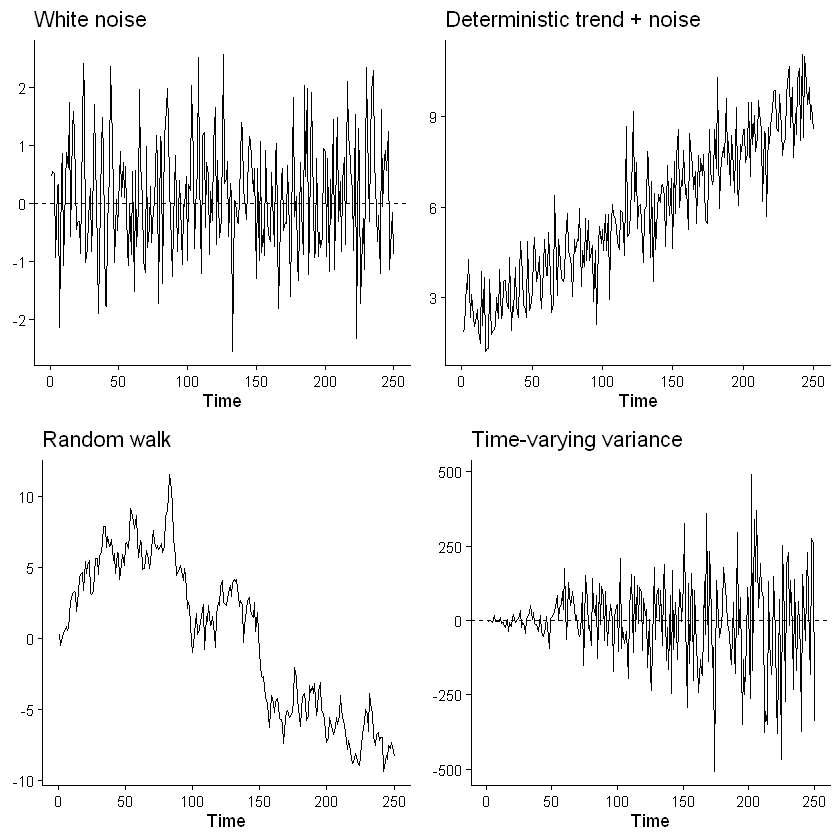

In [11]:
# Simulate four processes

set.seed(821)

T <- 250
t <- 1:T

wn    <- rnorm(T)
trend <- 2 + 0.03 * t + rnorm(T)
rw    <- cumsum(rnorm(T))
tvv   <- t * rnorm(T)

p1 <- ts_plot(wn, mu = 0)  + ggtitle("White noise")
p2 <- ts_plot(trend)       + ggtitle("Deterministic trend + noise")
p3 <- ts_plot(rw)          + ggtitle("Random walk")
p4 <- ts_plot(tvv, mu = 0) + ggtitle("Time-varying variance")

grid.arrange(p1, p2, p3, p4, ncol = 2)

**Reading the graphs**

- White noise fluctuates around a constant mean with constant variance.
- A deterministic trend violates the **constant-mean** condition.
- A random walk has
  $$
  \operatorname{Var}(Y_t)=t\sigma^2
  $$
  when $Y_0$ is fixed, so its variance changes with time.
- If $Y_t=t\varepsilon_t$, then
  $$
  E(Y_t)=0,
  \qquad
  \operatorname{Var}(Y_t)=t^2\sigma^2,
  $$
  so the process is nonstationary through its variance.

The graphs illustrate realizations. **Stationarity is a property of the stochastic process, not a visual property of one particular observed path.**


## Stationarity is not enough: ergodicity

Stationarity is a statement about the **rows** of a stochastic process: at every date the probability law is the same. Ergodicity is a different, and equally important, statement — it connects two ways of averaging that need not agree.

Picture the process as a grid. Each **column** is one complete history the world could have produced (one realisation $\omega$); each **row** is a fixed date $t$ seen across all those parallel histories.

- **Ensemble average** — average *down a row*, across parallel histories at a fixed $t$. This is the expectation $E(Y_t)$.
- **Time average** — average *along one cloumn*, over time within the single history we actually observe: $\dfrac{1}{T}\sum_{t=1}^{T}Y_t$.

$$
\underbrace{E(Y_t)}_{\text{along a row: across histories}}
\qquad\text{vs.}\qquad
\underbrace{\frac{1}{T}\sum_{t=1}^{T}Y_t}_{\text{down a column: one history}}
$$

A stationary process is **mean ergodic** when these two coincide as the sample grows:

$$
\frac{1}{T}\sum_{t=1}^{T}Y_t \xrightarrow{p} E(Y_t),
$$

where $\xrightarrow{p}$ is convergence in probability (stronger conditions give almost-sure convergence). The same idea extends to variances and autocovariances: **ergodicity is exactly what lets a time average from one path stand in for an ensemble average.**

**Why this is important in time-series econometrics.** We almost never get the grid — we get **one row**. There is one realized path of US GDP, one path of the S&P 500, one observed inflation series. Every time we estimate a mean, a variance, or an autocorrelation from that single path and treat it as a population quantity, we are assuming the process is ergodic. If it is not, collecting more of the *same* history does not help.

Two warnings the simulations will make concrete:

- **stationarity does not imply ergodicity** — a stable law can still hide a permanent, history-specific component;
- **serial dependence does not imply non-ergodicity** — strongly autocorrelated data (a stationary AR(1)) can still be ergodic.

### A real-world picture: permanent versus transitory

The example simulated below,

$$
Y_t = A + \varepsilon_t,
\qquad A \text{ drawn once},\quad \varepsilon_t \text{ transitory},
$$

is the **permanent–transitory** decomposition that runs through applied economics.

- Read $Y_t$ as a household's **log income** in year $t$. The permanent component $A$ — profession, human capital, region — is drawn once and carried for life; $\varepsilon_t$ is a good or bad year. This is the structure behind Friedman's *permanent-income hypothesis* and the modern income-dynamics literature.
- Or read $Y_t$ as a **country's** growth: a permanent "type" $A$ (institutions, geography) plus year-to-year shocks $\varepsilon_t$.

Now follow **one** household (or country) for a long time. Its time-average income converges to **its own** permanent draw $A$, not to the average across all households. Watching Argentina for two centuries reveals Argentina's $A$, not the world-average growth rate.

That is non-ergodicity: the permanent component never averages out **within a single column**, so one long history cannot recover the cross-sectional (ensemble) mean. Contrast this with a stationary AR(1), where a shock's influence decays, $\gamma_h=\phi^h\to0$, and a long enough path *does* recover the ensemble moments.

### Simulation 1: iid white noise

Let

$$
Y_t\overset{iid}{\sim}N(0,1),
\qquad
E(Y_t)=0,\qquad E(Y_t^2)=1,\qquad \gamma_1=0.
$$

We track three time averages at once: the running mean, the running second moment, and the running lag-1 product. These are the sample analogues of the three ensemble quantities above.

**Predict before running:** as the realization becomes longer, what should each of the three running quantities approach?

Warning message:
"Removed 1 row containing missing values or values outside the scale range (`geom_line()`)."


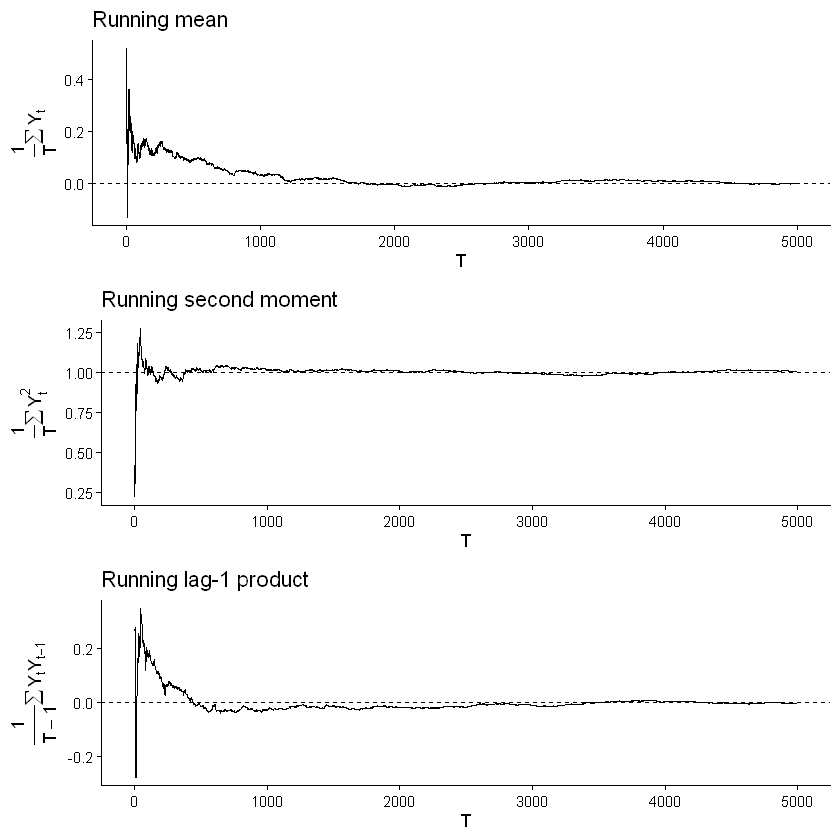

In [12]:
# Ergodic white noise: running mean, second moment, and lag-1 product

set.seed(821)

T <- 5000
y <- rnorm(T)
d <- running_moments(y)

p1 <- ggplot(d, aes(t, mean)) +
  geom_line() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  theme_classic() +
  labs(title = "Running mean", x = "T", y = expression(frac(1, T) * sum(Y[t])))

p2 <- ggplot(d, aes(t, second_moment)) +
  geom_line() +
  geom_hline(yintercept = 1, linetype = "dashed") +
  theme_classic() +
  labs(title = "Running second moment", x = "T", y = expression(frac(1, T) * sum(Y[t]^2)))

p3 <- ggplot(d, aes(t, lag1_product)) +
  geom_line() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  theme_classic() +
  labs(title = "Running lag-1 product", x = "T",
       y = expression(frac(1, T - 1) * sum(Y[t] * Y[t - 1])))

grid.arrange(p1, p2, p3, ncol = 1)

**What should you see?**

As $T$ increases,

$$
\frac{1}{T}\sum Y_t \xrightarrow{p} 0,
\qquad
\frac{1}{T}\sum Y_t^2 \xrightarrow{p} 1,
\qquad
\frac{1}{T-1}\sum_{t=2}^{T}Y_t Y_{t-1} \xrightarrow{p} 0.
$$

The path itself never becomes smooth. What stabilizes are the **time averages of functions of the process**.

### Simulation 2: dependence does not rule out ergodicity

Consider the stationary AR(1),

$$
Y_t=\phi Y_{t-1}+\varepsilon_t,
\qquad |\phi|<1.
$$

Set $\phi=0.8$ and choose $\operatorname{Var}(\varepsilon_t)=1-\phi^2$, so that

$$
E(Y_t)=0,\qquad \operatorname{Var}(Y_t)=1,\qquad \gamma_1=0.8.
$$

The process is serially dependent but ergodic.

**Predict:** should the running mean converge to zero? What should the running lag-1 product approach?


Warning message:
"Removed 1 row containing missing values or values outside the scale range (`geom_line()`)."


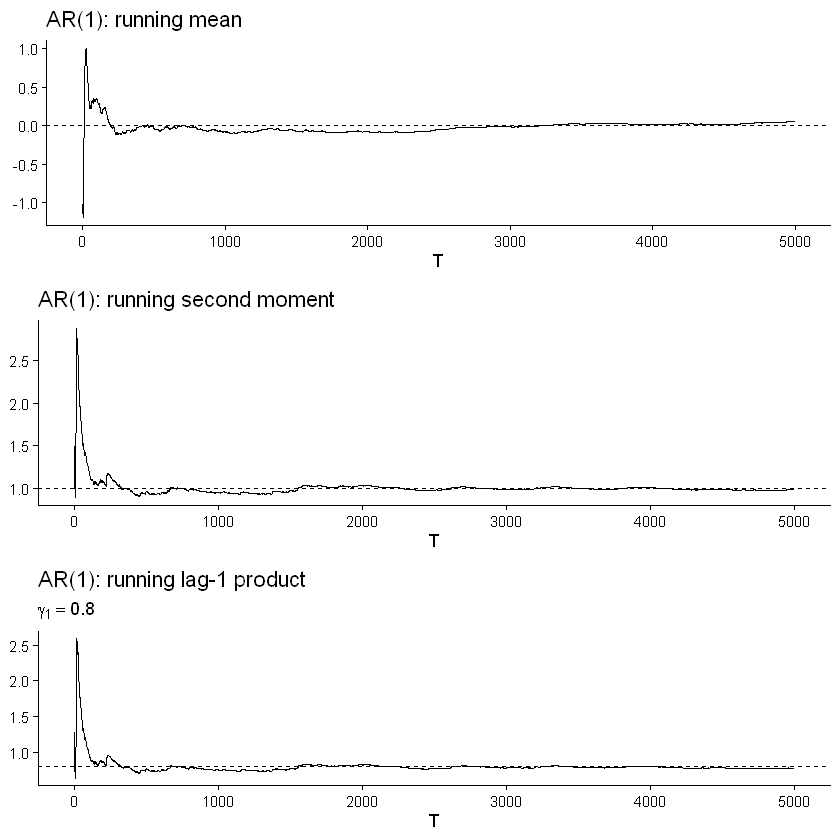

In [13]:
# Stationary and dependent, yet ergodic: AR(1)

set.seed(822)

T   <- 5000
phi <- 0.8
innovation_sd <- sqrt(1 - phi^2)          # normalises Var(Y_t) to 1

y_ar <- as.numeric(arima.sim(model = list(ar = phi), n = T, sd = innovation_sd))
d    <- running_moments(y_ar)

p1 <- ggplot(d, aes(t, mean)) +
  geom_line() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  theme_classic() +
  labs(title = "AR(1): running mean", x = "T", y = NULL)

p2 <- ggplot(d, aes(t, second_moment)) +
  geom_line() +
  geom_hline(yintercept = 1, linetype = "dashed") +
  theme_classic() +
  labs(title = "AR(1): running second moment", x = "T", y = NULL)

p3 <- ggplot(d, aes(t, lag1_product)) +
  geom_line() +
  geom_hline(yintercept = phi, linetype = "dashed") +
  theme_classic() +
  labs(title = "AR(1): running lag-1 product",
       subtitle = expression(gamma[1] == 0.8), x = "T", y = NULL)

grid.arrange(p1, p2, p3, ncol = 1)

For this stationary AR(1),

$$
\frac{1}{T}\sum_{t=1}^{T}Y_t \xrightarrow{p} 0,
\qquad
\frac{1}{T}\sum_{t=1}^{T}Y_t^2 \xrightarrow{p} 1,
\qquad
\frac{1}{T-1}\sum_{t=2}^{T}Y_t Y_{t-1} \xrightarrow{p} \gamma_1 = 0.8.
$$

> **Ergodicity does not require independence.**

The observations can be strongly serially correlated and the process can still reveal its stationary moments through a sufficiently long realization.

### Simulation 3: stationary but non-ergodic

Now consider

$$
Y_t=A+\varepsilon_t,
\qquad
A\sim N(0,1),
\qquad
\varepsilon_t\overset{iid}{\sim}N(0,1),
$$

where $A$ is drawn **once** and then held fixed for the entire realization.

Unconditionally the process is stationary:

$$
E(Y_t)=0,
\qquad
\operatorname{Var}(Y_t)=2,
\qquad
\gamma_h=\operatorname{Var}(A)=1 \quad (h>0).
$$

But within a single realization the permanent component $A$ never averages out. As $T\to\infty$,

$$
\frac{1}{T}\sum Y_t \to A,
\qquad
\frac{1}{T}\sum Y_t^2 \to A^2+1,
\qquad
\frac{1}{T-1}\sum_{t=2}^{T}Y_t Y_{t-1} \to A^2,
$$

rather than the ensemble values $0$, $2$, and $1$. The three running diagnostics below therefore settle on **realization-specific** limits (dashed), not the ensemble values (dotted).

Warning message:
"Removed 1 row containing missing values or values outside the scale range (`geom_line()`)."


Realization-specific A = -0.9929 


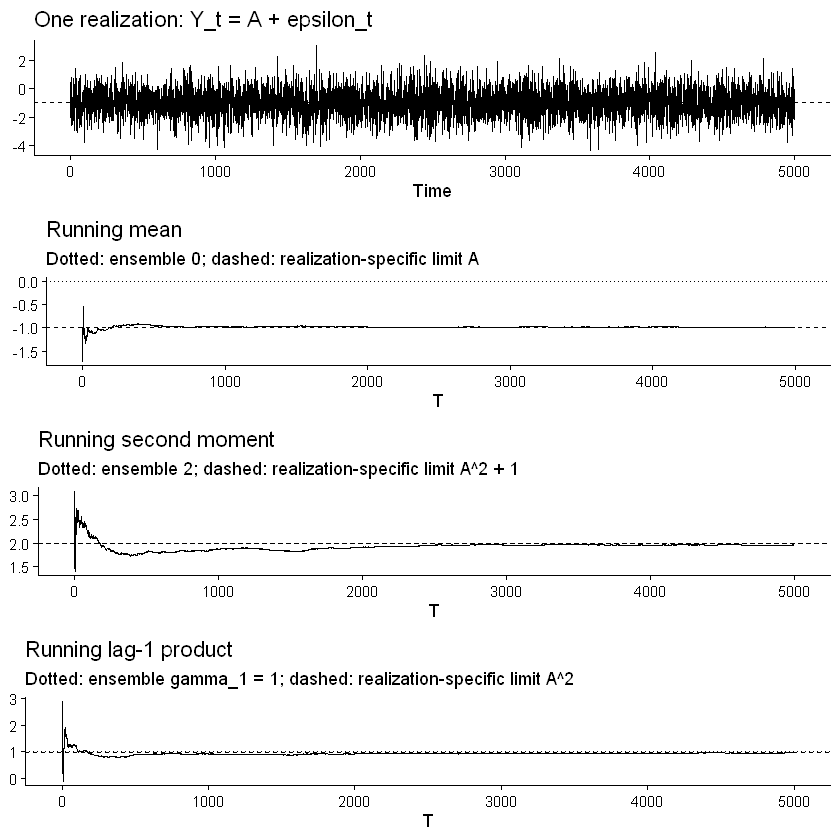

In [14]:
# Stationary but non-ergodic: a permanent random component

set.seed(823)

T <- 5000
A <- rnorm(1)
epsilon <- rnorm(T)
y_ne <- A + epsilon
d <- running_moments(y_ne)

p0 <- ts_plot(y_ne) +
  geom_hline(yintercept = A, linetype = "dashed") +
  ggtitle("One realization: Y_t = A + epsilon_t")

p1 <- ggplot(d, aes(t, mean)) +
  geom_line() +
  geom_hline(yintercept = 0, linetype = "dotted") +
  geom_hline(yintercept = A, linetype = "dashed") +
  theme_classic() +
  labs(title = "Running mean",
       subtitle = "Dotted: ensemble 0; dashed: realization-specific limit A",
       x = "T", y = NULL)

p2 <- ggplot(d, aes(t, second_moment)) +
  geom_line() +
  geom_hline(yintercept = 2, linetype = "dotted") +
  geom_hline(yintercept = A^2 + 1, linetype = "dashed") +
  theme_classic() +
  labs(title = "Running second moment",
       subtitle = "Dotted: ensemble 2; dashed: realization-specific limit A^2 + 1",
       x = "T", y = NULL)

p3 <- ggplot(d, aes(t, lag1_product)) +
  geom_line() +
  geom_hline(yintercept = 1, linetype = "dotted") +
  geom_hline(yintercept = A^2, linetype = "dashed") +
  theme_classic() +
  labs(title = "Running lag-1 product",
       subtitle = "Dotted: ensemble gamma_1 = 1; dashed: realization-specific limit A^2",
       x = "T", y = NULL)

grid.arrange(p0, p1, p2, p3, ncol = 1)

cat("Realization-specific A =", round(A, 4), "\n")

### Why stationarity does not imply ergodicity here

The process $Y_t=A+\varepsilon_t$ is stationary because shifting time does not change its joint distribution.

But the common component $A$ creates dependence that never dies out:

$$
\gamma_h=1
\qquad
\text{for every }h>0.
$$

By contrast, for a stationary AR(1),

$$
\gamma_h\propto\phi^h\rightarrow0
\qquad (|\phi|<1).
$$

The difference is not simply whether observations are dependent, but whether the dependence is sufficiently persistent to prevent time averages from revealing ensemble moments.


### Many realizations make the distinction visible

Generate many realizations of increasing length and compare their time averages.

- For an ergodic process, time averages should become concentrated around the ensemble mean.
- For $Y_t=A+\varepsilon_t$, transitory noise averages out, but the realization-specific component $A$ remains.

Predict what should happen before running the simulation.


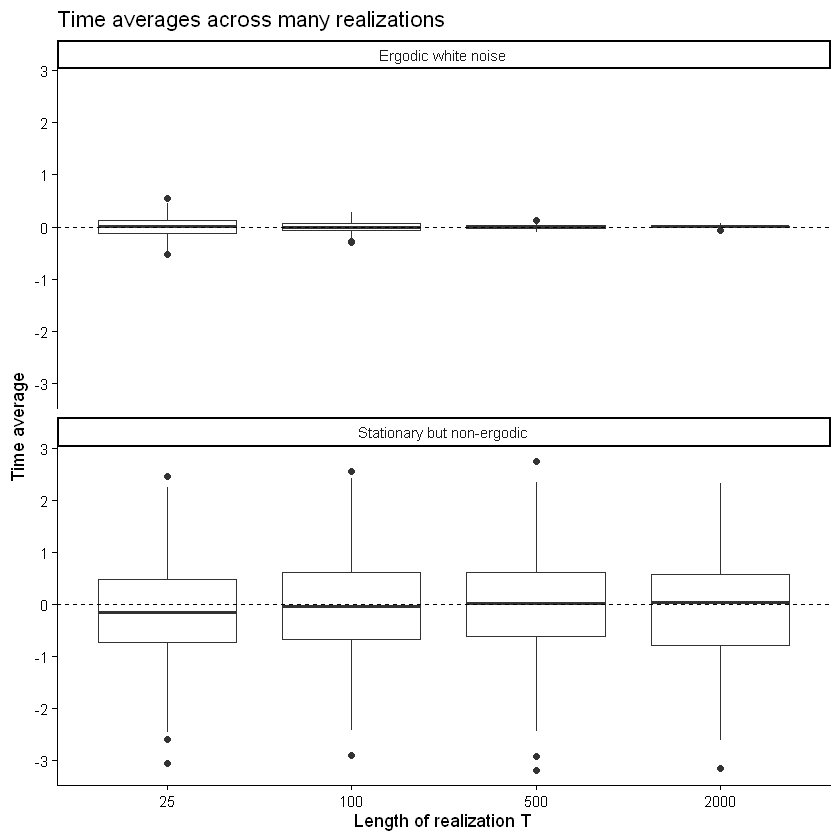

In [15]:
# Many realizations: does increasing T make the time average concentrate?

set.seed(824)

T_values <- c(25, 100, 500, 2000)
R <- 300

results <- do.call(
  rbind,
  lapply(T_values, function(Ti) {

    wn_means <- replicate(
      R,
      mean(rnorm(Ti))
    )

    nonergodic_means <- replicate(
      R,
      {
        A_i <- rnorm(1)
        mean(A_i + rnorm(Ti))
      }
    )

    rbind(
      data.frame(
        T = factor(Ti, levels = T_values),
        process = "Ergodic white noise",
        time_mean = wn_means
      ),
      data.frame(
        T = factor(Ti, levels = T_values),
        process = "Stationary but non-ergodic",
        time_mean = nonergodic_means
      )
    )
  })
)

ggplot(results, aes(x = T, y = time_mean)) +
  geom_boxplot() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  facet_wrap(~ process, ncol = 1) +
  theme_classic() +
  labs(
    title = "Time averages across many realizations",
    x = "Length of realization T",
    y = "Time average"
  )


**Interpretation**

For white noise, the distribution of time averages collapses toward zero as $T$ increases.

For $Y_t=A+\varepsilon_t$, each realization instead converges toward its own draw of $A$. The distribution of time averages therefore does **not** collapse to the ensemble mean.

> Ergodicity is what allows a long history to substitute, in an appropriate sense, for repeated draws from the ensemble.


## Why ergodicity changes decisions: a betting example

The cases above are additive and stationary. The most consequential real-world failures of ergodicity are often **multiplicative**, and they change what "a good bet" even means. This is the core of what is now called **ergodicity economics** (associated with Ole Peters).

Consider a repeated gamble on your wealth $W_t$. Each period, independently,

$$
W_t =
\begin{cases}
1.5\,W_{t-1} & \text{prob } 0.5 \quad(\text{gain } 50\%),\\[4pt]
0.6\,W_{t-1} & \text{prob } 0.5 \quad(\text{lose } 40\%).
\end{cases}
$$

**Ensemble view — average down the row (across many parallel gamblers).**

$$
E\!\left[\frac{W_t}{W_{t-1}}\right] = 0.5(1.5)+0.5(0.6) = 1.05,
\qquad\Rightarrow\qquad
E[W_t] = (1.05)^t W_0,
$$

so expected wealth grows about **5% per period**. Judged by its expectation, the bet looks excellent.

**Time view — average along one column (one gambler's path).** By a law of large numbers on the log-multipliers,

$$
\frac{1}{t}\log\frac{W_t}{W_0}
\xrightarrow{p}
0.5\log 1.5 + 0.5\log 0.6 \approx -0.053,
$$

so a **typical path shrinks about 5% per period** and $W_t \to 0$ almost surely.

The expectation (across parallel worlds) and the growth actually *experienced* along one path point in **opposite directions**. Because a real investor lives one path, the time average — not the expectation — is the decision-relevant number. This is exactly why compounded (geometric) returns, "volatility drag," and the Kelly criterion matter, and why judging a repeated financial gamble by its expected value alone is misleading.

**Predict before running:** as $t$ grows, what happens to (i) the average wealth across many gamblers, and (ii) the wealth of the *typical* gambler?

Ensemble growth per period : 1.050  (E[multiplier])
Time-average growth/period : 0.949  (geometric mean)


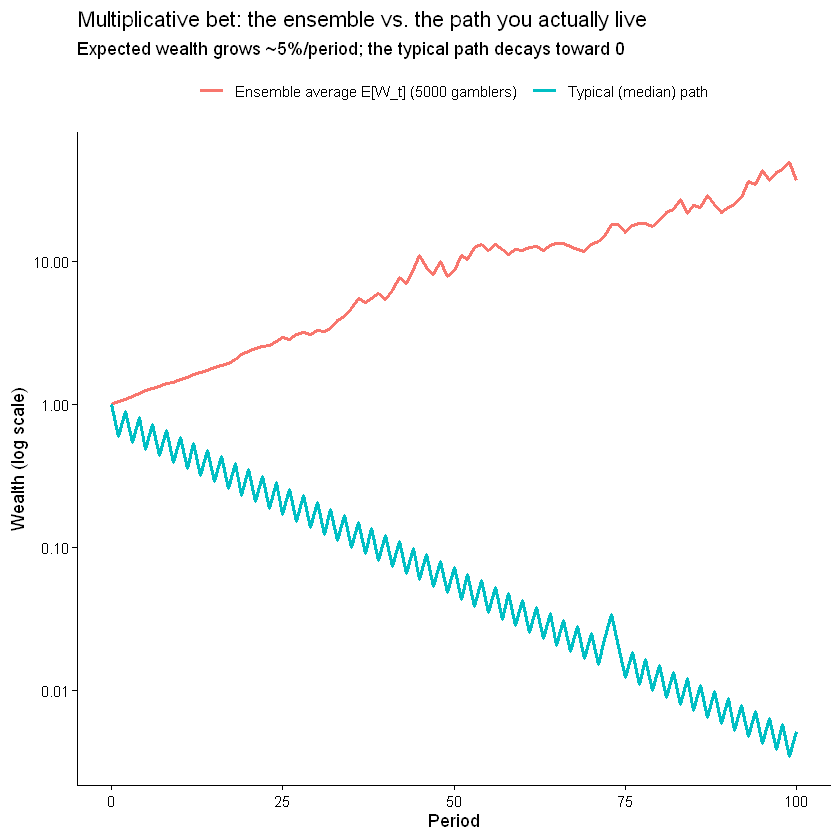

In [16]:
# Multiplicative bet: ensemble average rises while the typical path collapses
set.seed(826)

n_paths <- 5000
Tn      <- 100

# Each step multiplies wealth by 1.5 (gain 50%) or 0.6 (lose 40%), prob 1/2 each.
multipliers <- matrix(sample(c(1.5, 0.6), n_paths * Tn, replace = TRUE),
                      nrow = n_paths)
wealth <- cbind(1, t(apply(multipliers, 1, cumprod)))   # W_0 = 1 in the first column

t_idx         <- 0:Tn
ensemble_mean <- colMeans(wealth)          # average across the 5000 gamblers
median_path   <- apply(wealth, 2, median)  # the typical gambler

# Theoretical references
ens_theory <- 1.05^t_idx
geo_rate   <- exp(0.5 * log(1.5) + 0.5 * log(0.6))   # ~ 0.9487 per period
geo_theory <- geo_rate^t_idx

plot_df <- rbind(
  data.frame(t = t_idx, wealth = ensemble_mean, series = "Ensemble average E[W_t] (5000 gamblers)"),
  data.frame(t = t_idx, wealth = median_path,   series = "Typical (median) path")
)

ggplot(plot_df, aes(t, wealth, colour = series)) +
  geom_line(linewidth = 1) +
  scale_y_log10() +
  theme_classic() +
  theme(legend.position = "top", legend.title = element_blank()) +
  labs(title = "Multiplicative bet: the ensemble vs. the path you actually live",
       subtitle = "Expected wealth grows ~5%/period; the typical path decays toward 0",
       x = "Period", y = "Wealth (log scale)")

cat(sprintf("Ensemble growth per period : %.3f  (E[multiplier])\n", 1.05))
cat(sprintf("Time-average growth/period : %.3f  (geometric mean)\n", geo_rate))

**What the picture shows**

The two lines diverge on a log scale. The ensemble average climbs, matching $E[W_t]=1.05^t$ — but it is propped up by a handful of extraordinarily lucky paths in which $1.5$ came up far more often than $0.6$. The typical (median) gambler tracks the geometric rate $\approx 0.95$ per period and heads toward zero.

- **Ensemble average** answers: "mean wealth across many parallel gamblers." $\to 1.05^t$.
- **Time/path view** answers: "what happens to *me* if I keep playing." $\to (0.95)^t$.

Because these disagree, the process is **non-ergodic**: no single path's time average converges to the ensemble mean. And since you only ever live one path, the ensemble expectation is the wrong basis for the decision.

This is the same lesson as $Y_t=A+\varepsilon_t$ — one realization need not reveal the ensemble — now in a multiplicative, decision-relevant form.

### Summary: stationarity and ergodicity

| Process | Stationary? | Serial dependence? | Mean ergodic? | Long-run covariance |
|---|:---:|:---:|:---:|---|
| iid white noise | Yes | No | Yes | $\gamma_h=0$ for $h>0$ |
| stationary AR(1), $|\phi|<1$ | Yes | Yes | Yes | $\gamma_h\to0$ |
| $Y_t=A+\varepsilon_t$ | Yes | Yes | No | $\gamma_h=1$ for all $h>0$ |
| random walk | No | Yes | — | variance grows with $t$ |

Remember:

$$
\boxed{\text{stationary} \not\Rightarrow \text{ergodic}},
\qquad
\boxed{\text{dependence} \not\Rightarrow \text{non-ergodic}}.
$$


## White noise

A **white-noise process** $\{\varepsilon_t\}$ satisfies

$$
E(\varepsilon_t)=0,
\qquad
\operatorname{Var}(\varepsilon_t)=\sigma^2,
$$

and

$$
\operatorname{Cov}(\varepsilon_t,\varepsilon_{t-h})=0
\qquad (h\neq0).
$$

Therefore its theoretical ACF is

$$
\rho_0=1,
\qquad
\rho_h=0\quad(h\neq0).
$$

White noise means **serially uncorrelated**. It does not, by itself, imply independence.

Useful distinctions:

- **iid white noise:** independent and identically distributed;
- **Gaussian white noise:** a jointly Gaussian process that is white noise; in this case zero autocovariances imply independence across time;
- **martingale difference sequence:** $E(\varepsilon_t\mid\mathcal F_{t-1})=0$.

These concepts overlap, but they are not equivalent.


### Population ACF versus sample ACF

The **population ACF** is a property of the stochastic process. The **sample ACF** is an estimate computed from one finite realization.

For white noise,

$$
\rho_h=0
\qquad (h>0),
$$

but a finite sample will almost never produce sample autocorrelations that are exactly zero.

The simulation below compares realizations of length $T=100$ and $T=1000$.

**Predict:** which sample ACF should lie more tightly around zero?


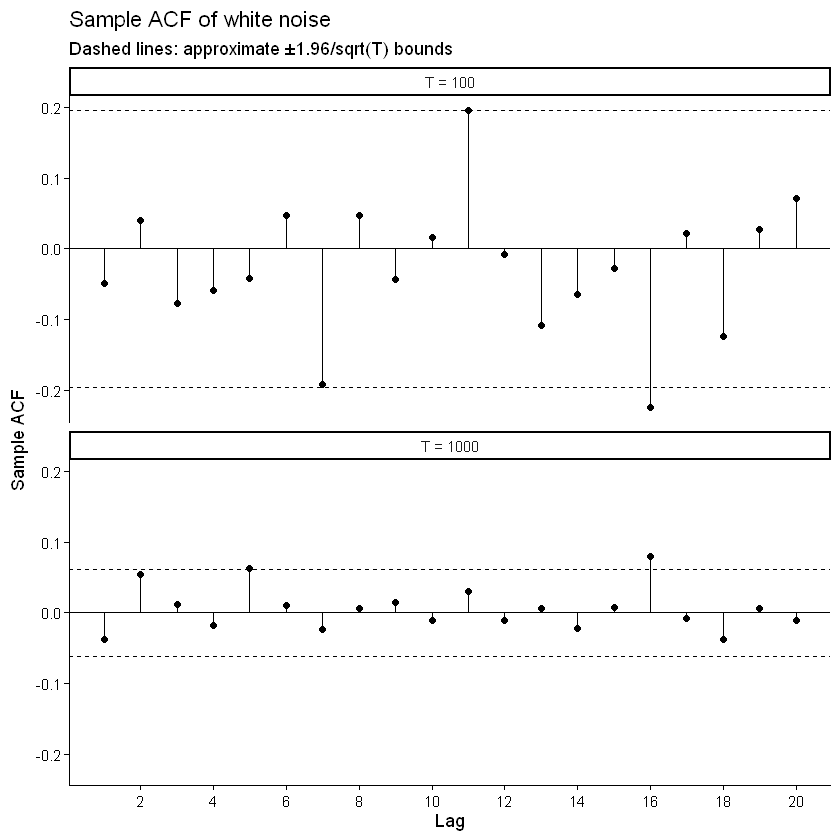

In [18]:
# Population ACF versus sample ACF for white noise

set.seed(825)

sample_acf_df <- function(n, max_lag = 20) {
  x <- rnorm(n)
  a <- acf(x, plot = FALSE, lag.max = max_lag)

  data.frame(
    lag = as.numeric(a$lag[-1]),
    acf = as.numeric(a$acf[-1]),
    n = paste0("T = ", n),
    bound = 1.96 / sqrt(n)
  )
}

acf_samples <- rbind(
  sample_acf_df(100),
  sample_acf_df(1000)
)

bounds <- unique(acf_samples[c("n", "bound")])

ggplot(acf_samples, aes(lag, acf)) +
  geom_hline(yintercept = 0) +
  geom_segment(aes(xend = lag, y = 0, yend = acf)) +
  geom_point() +
  geom_hline(
    data = bounds,
    aes(yintercept = bound),
    linetype = "dashed"
  ) +
  geom_hline(
    data = bounds,
    aes(yintercept = -bound),
    linetype = "dashed"
  ) +
  facet_wrap(~ n, ncol = 1) +
  theme_classic() +
  scale_x_continuous(breaks = seq(0, 20, by = 2)) +
  labs(
    title = "Sample ACF of white noise",
    subtitle = "Dashed lines: approximate ±1.96/sqrt(T) bounds",
    x = "Lag",
    y = "Sample ACF"
  )


**Interpretation**

The population ACF is zero at every positive lag, yet the sample ACF fluctuates around zero because it is computed from one realization.

As the sample grows, these sampling fluctuations typically become smaller. This is where the distinction between a **stochastic process** and an **observed realization** becomes operational.


## A stationary process and a random walk from the same shocks

Let

$$
X_t=
\begin{cases}
+1,&P=0.5,\\
-1,&P=0.5.
\end{cases}
$$

with independent draws over time. Then

$$
E(X_t)=0,
\qquad
\operatorname{Var}(X_t)=1,
\qquad
\gamma_h=0\quad(h\neq0),
$$

so $\{X_t\}$ is covariance stationary.

Now accumulate exactly the same shocks:

$$
Y_t=Y_{t-1}+X_t,
\qquad
Y_0=0.
$$

Then

$$
Y_t=\sum_{i=1}^{t}X_i,
$$

and

$$
\operatorname{Var}(Y_t)=t.
$$

The shocks are stationary; their accumulation is not.


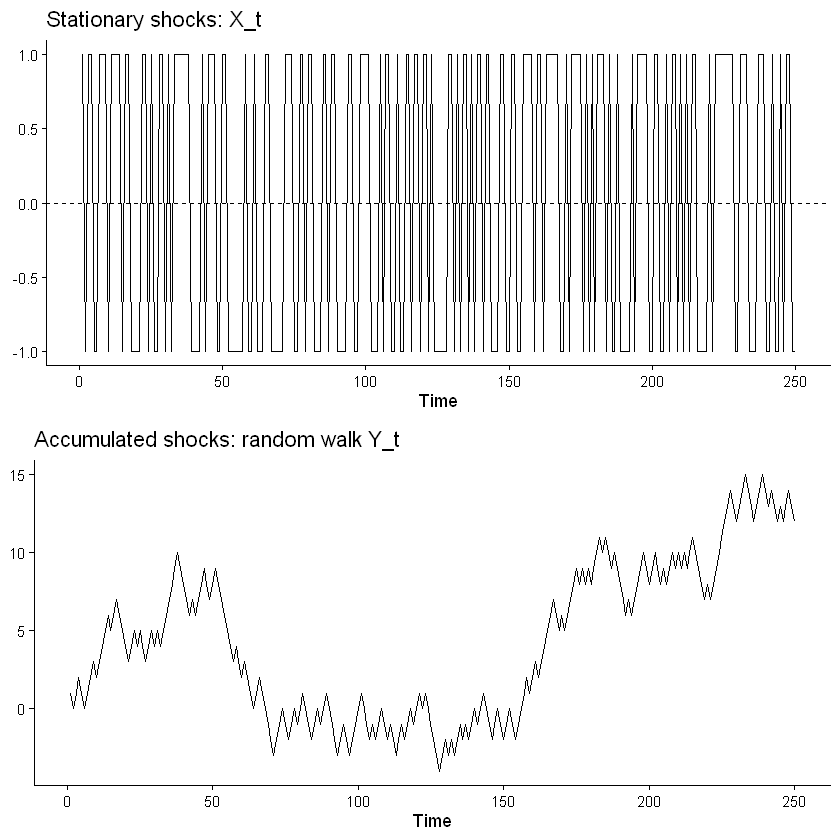

In [19]:
# Same shocks, very different time-series properties

set.seed(100)

n <- 250
X <- sample(c(-1, 1), n, replace = TRUE)
Y <- cumsum(X)

p1 <- ts_plot(X, mu = 0) + ggtitle("Stationary shocks: X_t")
p2 <- ts_plot(Y)         + ggtitle("Accumulated shocks: random walk Y_t")

grid.arrange(p1, p2, ncol = 1)

### Differencing changes the process

For the random walk

$$
Y_t=Y_{t-1}+\varepsilon_t,
$$

the level is nonstationary because

$$
\operatorname{Var}(Y_t)=t\sigma^2.
$$

But

$$
\Delta Y_t
=
Y_t-Y_{t-1}
=
\varepsilon_t,
$$

which is stationary white noise.

This distinction between the properties of a **level** and its **difference** will become central when we study unit roots and integrated processes.


# Linear representations of stationary time series

## Wold decomposition

For a covariance-stationary, **purely nondeterministic** process,

$$
Y_t-\mu
=
\varepsilon_t
+\psi_1\varepsilon_{t-1}
+\psi_2\varepsilon_{t-2}
+\cdots
=
\sum_{j=0}^{\infty}\psi_j\varepsilon_{t-j},
$$

where

$$
\psi_0=1,
\qquad
\sum_{j=0}^{\infty}\psi_j^2<\infty.
$$

Here $\varepsilon_t$ is the **innovation**: the one-step-ahead **linear projection error** based on the past. Innovations are serially uncorrelated by construction; they need not be iid or Gaussian.

A general covariance-stationary process can also contain a deterministic component. Wold's moving-average representation describes its purely nondeterministic component.

### Why Wold matters

Wold provides a general dynamic representation:

> today's value can be written as the accumulated effects of current and past innovations.

Equivalently,

$$
Y_t=\widehat Y_{t|t-1}+\varepsilon_t,
$$

where $\widehat Y_{t|t-1}$ is the best linear forecast from the past.

> **Important:** a Wold innovation is a statistical innovation. It should not automatically be interpreted as a **causal structural shock**. It is also defined relative to linear prediction; a nonlinear forecasting model may exploit information that a linear projection does not.


### Moments of a linear process

Suppose

$$
Y_t
=
\mu+\sum_{j=0}^{\infty}\psi_j\varepsilon_{t-j},
\qquad
\varepsilon_t\sim WN(0,\sigma^2).
$$

Then

$$
E(Y_t)=\mu.
$$

If $\sum_{j=0}^{\infty}\psi_j^2<\infty$,

$$
\gamma_0
=
\sigma^2\sum_{j=0}^{\infty}\psi_j^2.
$$

For $h\ge0$,

$$
\gamma_h
=
\sigma^2
\sum_{j=0}^{\infty}
\psi_j\psi_{j+h}.
$$

This formula links the **dynamic response coefficients** $\{\psi_j\}$ to the **dependence structure** $\{\gamma_h\}$.


## Lag operator

The **lag operator** $L$ shifts a variable back one period:

$$
LY_t=Y_{t-1},
\qquad
L^jY_t=Y_{t-j}.
$$

For example,

$$
Y_t
=
\mu+\varepsilon_t
+\theta_1\varepsilon_{t-1}
+\theta_2\varepsilon_{t-2}
$$

can be written as

$$
Y_t-\mu
=
(1+\theta_1L+\theta_2L^2)\varepsilon_t
=
\theta(L)\varepsilon_t.
$$

Lag-polynomial notation makes the properties of AR, MA, and ARMA processes considerably easier to express.


## Familiar linear-process families

With white-noise innovations $\varepsilon_t$:

**AR($p$):**
$$
Y_t
=
c+\phi_1Y_{t-1}+\cdots+\phi_pY_{t-p}+\varepsilon_t.
$$

**MA($q$):**
$$
Y_t
=
\mu+\varepsilon_t+\theta_1\varepsilon_{t-1}
+\cdots+\theta_q\varepsilon_{t-q}.
$$

**ARMA($p,q$):**
$$
Y_t
=
c+\phi_1Y_{t-1}+\cdots+\phi_pY_{t-p}
+\varepsilon_t+\theta_1\varepsilon_{t-1}
+\cdots+\theta_q\varepsilon_{t-q}.
$$

This lecture concentrates on **MA processes**. Their finite-order stationarity is automatic when the innovations are white noise with finite variance. AR and ARMA properties follow in subsequent lectures.


# Moving-average processes

## MA(1)

Consider

$$
Y_t
=
\mu+\varepsilon_t+\theta\varepsilon_{t-1},
\qquad
\varepsilon_t\sim WN(0,\sigma^2).
$$

The mean is

$$
E(Y_t)=\mu.
$$

The autocovariances are

$$
\gamma_h=
\begin{cases}
(1+\theta^2)\sigma^2, & h=0,\\[4pt]
\theta\sigma^2, & |h|=1,\\[4pt]
0, & |h|>1.
\end{cases}
$$

Hence

$$
\rho_1
=
\frac{\theta}{1+\theta^2},
\qquad
\rho_h=0\quad(|h|>1).
$$

### Properties of an MA(1)

- The theoretical ACF **cuts off after lag 1**.
- The sign of $\rho_1$ is the sign of $\theta$.
- Since
  $$
  \left|\frac{\theta}{1+\theta^2}\right|\le\frac12,
  $$
  an MA(1) can never have $|\rho_1|>0.5$.


### Predict before running the code

Compare

$$
Y_t=2+\varepsilon_t+0.8\varepsilon_{t-1}
$$

and

$$
Y_t=2+\varepsilon_t-0.8\varepsilon_{t-1}.
$$

Before looking at the graphs:

1. What sign should $\rho_1$ have in each process?
2. What is the numerical value of $\rho_1$?
3. At which lag must the theoretical ACF become exactly zero?
4. Will the two simulated paths necessarily look obviously different?


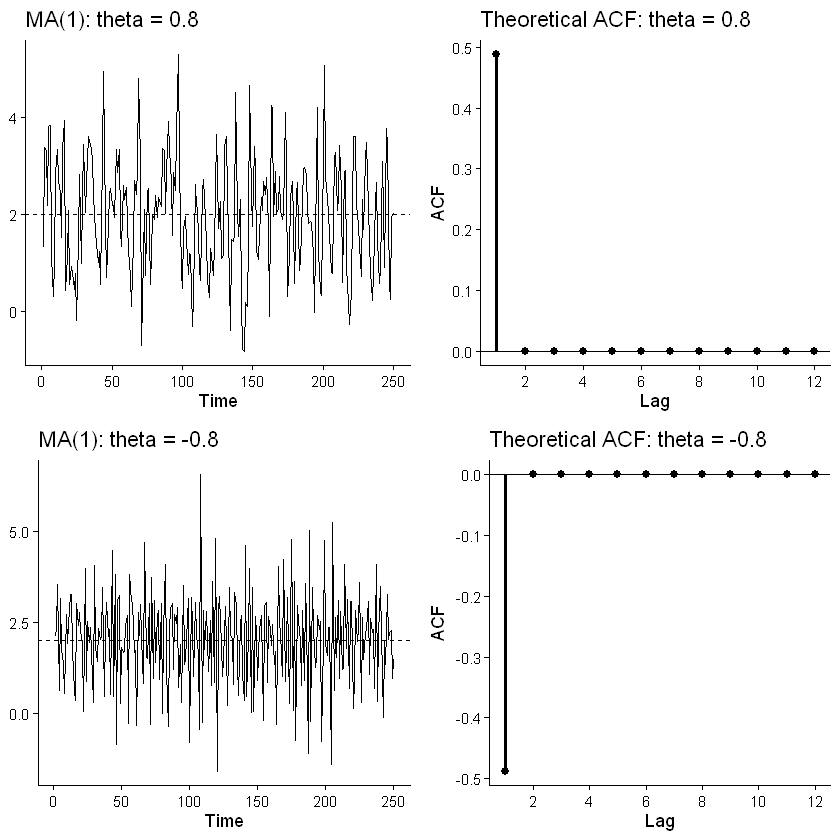

In [20]:
# Simulated realizations and theoretical ACFs of two MA(1) processes

set.seed(123)

n <- 250

ma_pos <- 2 + arima.sim(model = list(ma =  0.8), n = n)
ma_neg <- 2 + arima.sim(model = list(ma = -0.8), n = n)

p1 <- ts_plot(ma_pos, mu = 2) + ggtitle("MA(1): theta = 0.8")
p2 <- acf_plot(ma = 0.8,  L = 12, title = "Theoretical ACF: theta = 0.8")
p3 <- ts_plot(ma_neg, mu = 2) + ggtitle("MA(1): theta = -0.8")
p4 <- acf_plot(ma = -0.8, L = 12, title = "Theoretical ACF: theta = -0.8")

grid.arrange(p1, p2, p3, p4, ncol = 2)

**Reading the graphs**

For $\theta=0.8$,

$$
\rho_1
=
\frac{0.8}{1+0.8^2}
\approx0.488.
$$

For $\theta=-0.8$,

$$
\rho_1\approx-0.488.
$$

In both cases,

$$
\rho_h=0
\qquad
\text{for }|h|>1.
$$

The left-hand plots are particular **realizations**. The right-hand plots show the **theoretical ACFs** of the underlying stochastic processes.


## MA($q$)

Write an MA($q$) process as

$$
Y_t
=
\mu+\sum_{j=0}^{q}\theta_j\varepsilon_{t-j},
\qquad
\theta_0=1,
\qquad
\varepsilon_t\sim WN(0,\sigma^2).
$$

For $h=0,1,\ldots,q$,

$$
\gamma_h
=
\sigma^2
\sum_{j=0}^{q-h}
\theta_j\theta_{j+h},
$$

while

$$
\gamma_h=0
\qquad
\text{for }h>q.
$$

Therefore

$$
\rho_h=\frac{\gamma_h}{\gamma_0},
$$

and the theoretical ACF of an MA($q$) **cuts off after lag $q$**.

The reason is specific to linear dependence through the innovations: once $h>q$, $Y_t$ and $Y_{t-h}$ share no common innovations, so their autocovariance is zero.


### MA(2): work from the common shocks

Consider

$$
Y_{1t}
=
2+\varepsilon_t
+1.0\varepsilon_{t-1}
+0.7\varepsilon_{t-2},
$$

and

$$
Y_{2t}
=
2+\varepsilon_t
-1.2\varepsilon_{t-1}
+0.25\varepsilon_{t-2}.
$$

Before running the code:

1. At which lag must each ACF become zero?
2. For $Y_{1t}$, what signs do you expect for $\gamma_1$ and $\gamma_2$?
3. For $Y_{2t}$, can $\gamma_1$ and $\gamma_2$ have different signs?

Use

$$
\gamma_h
=
\sigma^2\sum_{j=0}^{q-h}
\theta_j\theta_{j+h}
$$

to answer before checking the graph.


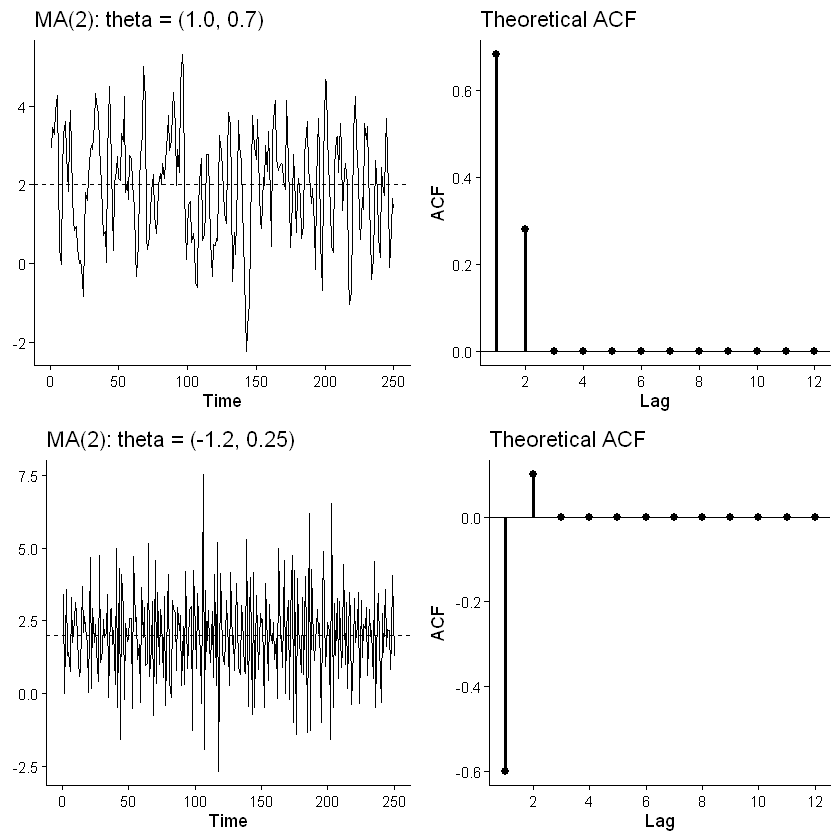

In [21]:
# Two MA(2) processes: realizations and theoretical ACFs

set.seed(123)

n <- 250
ma21 <- c(1.0, 0.7)
ma22 <- c(-1.2, 0.25)

s21 <- 2 + arima.sim(model = list(ma = ma21), n = n)
s22 <- 2 + arima.sim(model = list(ma = ma22), n = n)

p1 <- ts_plot(s21, mu = 2) + ggtitle("MA(2): theta = (1.0, 0.7)")
p2 <- acf_plot(ma = ma21, L = 12, title = "Theoretical ACF")
p3 <- ts_plot(s22, mu = 2) + ggtitle("MA(2): theta = (-1.2, 0.25)")
p4 <- acf_plot(ma = ma22, L = 12, title = "Theoretical ACF")

grid.arrange(p1, p2, p3, p4, ncol = 2)

For the first MA(2), using $\gamma_h=\sigma^2\sum_{j=0}^{q-h}\theta_j\theta_{j+h}$ with $\theta_0=1$,

$$
\gamma_1
=
\sigma^2(\theta_0\theta_1+\theta_1\theta_2)
=
\sigma^2(\theta_1+\theta_1\theta_2)
=
1.7\,\sigma^2,
$$

and

$$
\gamma_2
=
\sigma^2\,\theta_0\theta_2
=
0.7\,\sigma^2.
$$

For the second,

$$
\gamma_1
=
\sigma^2\big[\theta_0\theta_1+\theta_1\theta_2\big]
=
\sigma^2\big[-1.2+(-1.2)(0.25)\big]
=
-1.5\,\sigma^2,
$$

while

$$
\gamma_2
=
\sigma^2\,\theta_0\theta_2
=
0.25\,\sigma^2.
$$

Thus an MA(2) can display autocorrelations of different signs at lags 1 and 2. In both processes the theoretical ACF is exactly zero for $h>2$.

## Invertibility

Every finite MA process is covariance stationary, but different MA parameterizations can generate the same autocovariance structure.

For an MA(1),

$$
\rho_1=\frac{\theta}{1+\theta^2},
$$

so $\theta$ and $1/\theta$ produce the same $\rho_1$. For example,

$$
\theta=0.5
\qquad\text{and}\qquad
\theta=2
$$

both imply $\rho_1=0.4$.

If the innovation variance is rescaled appropriately, the two representations generate the same entire autocovariance function.

**Invertibility** selects the representation in which the innovation can be recovered as a convergent function of current and past observations.

For

$$
Y_t-\mu=(1+\theta L)\varepsilon_t,
$$

formally,

$$
\varepsilon_t
=
(1+\theta L)^{-1}(Y_t-\mu)
=
\left(1-\theta L+\theta^2L^2-\cdots\right)(Y_t-\mu).
$$

This expansion converges when $|\theta|<1$.

Thus invertibility concerns the **uniqueness and recoverability of the innovation representation**; it is not a stationarity condition for an MA process.


In [22]:
# Same MA(1) autocovariance structure, different parameterizations

equivalent_ma1 <- data.frame(
  theta = c(0.5, 2.0),
  sigma2 = c(1.0, 0.25)
)

equivalent_ma1$gamma0 <-
  equivalent_ma1$sigma2 * (1 + equivalent_ma1$theta^2)

equivalent_ma1$gamma1 <-
  equivalent_ma1$sigma2 * equivalent_ma1$theta

equivalent_ma1$rho1 <-
  equivalent_ma1$gamma1 / equivalent_ma1$gamma0

equivalent_ma1


theta,sigma2,gamma0,gamma1,rho1
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.5,1.00,1.25,0.5,0.4
2.0,0.25,1.25,0.5,0.4


### Root condition

For

$$
Y_t-\mu
=
(1+\theta L)\varepsilon_t,
$$

invertibility requires the root of

$$
1+\theta z=0
$$

to lie **outside the unit circle**.

The root is

$$
z=-\frac{1}{\theta},
$$

so for an MA(1),

$$
|\theta|<1.
$$

More generally, an MA($q$) process is invertible when every root of

$$
1+\theta_1z+\cdots+\theta_qz^q=0
$$

lies outside the unit circle.

> A coefficient larger than one does not, by itself, determine invertibility for an MA(2) or higher-order process. The condition applies to the **roots of the complete lag polynomial**.


In [23]:
# Check invertibility of the two MA(2) examples

ma_roots <- function(theta) {
  roots <- polyroot(c(1, theta))
  data.frame(
    root = roots,
    modulus = Mod(roots),
    outside_unit_circle = Mod(roots) > 1
  )
}

ma_roots(ma21)
ma_roots(ma22)


root,modulus,outside_unit_circle
<cpl>,<dbl>,<lgl>
-0.7142857+0.9583148i,1.195229,TRUE
-0.7142857-0.9583148i,1.195229,TRUE


root,modulus,outside_unit_circle
<cpl>,<dbl>,<lgl>
1.07335-5.04871e-29i,1.07335,TRUE
3.72665+5.04871e-29i,3.72665,TRUE


## Wold coefficients as dynamic responses

In the Wold representation,

$$
Y_t-\mu
=
\sum_{j=0}^{\infty}
\psi_j\varepsilon_{t-j},
$$

the coefficient $\psi_j$ measures the linear response at horizon $j$ to a one-unit innovation today.

For an MA($q$), the response becomes exactly zero after horizon $q$. For an infinite-order MA representation, it may decay gradually.

> These are responses to **statistical innovations**. A causal interpretation requires additional identification assumptions.

### Predict first

For

$$
Y_t
=
\varepsilon_t
+0.8\varepsilon_{t-1},
$$

what is the response to a one-unit innovation:

- immediately?
- one period later?
- two periods later?


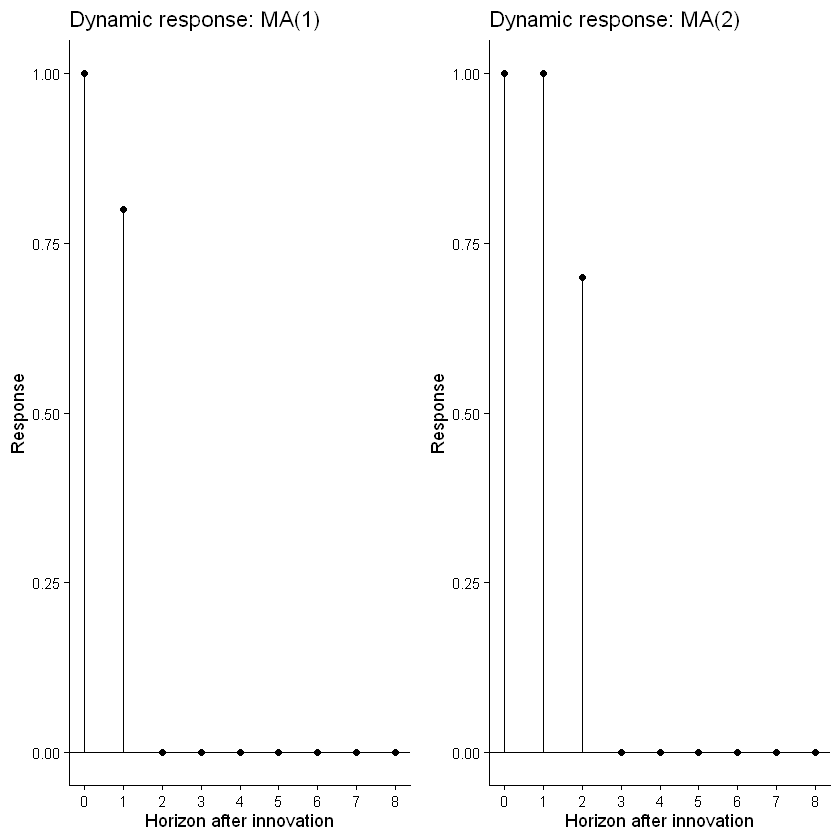

In [24]:
# Dynamic responses of MA processes (uses irf_ma defined in the setup cell)

p1 <- irf_ma(0.8,        h = 8, title = "Dynamic response: MA(1)")
p2 <- irf_ma(c(1.0, 0.7), h = 8, title = "Dynamic response: MA(2)")

grid.arrange(p1, p2, ncol = 2)

## Key takeaways

You should now be able to:

- distinguish a stochastic process from one observed realization;
- explain covariance stationarity, and ergodicity as the equality of time and ensemble averages;
- give an economic or financial example where ergodicity fails (permanent income; a multiplicative bet);
- interpret population autocovariances and autocorrelations;
- distinguish white noise from independence;
- explain Wold innovations and their role in linear forecasting;
- derive the ACF of MA(1) and MA($q$) processes;
- explain why an MA($q$) ACF cuts off after lag $q$;
- distinguish stationarity from invertibility and check the MA root condition.


## Exercises

### Exercise 1: What property fails?

For each process, determine whether it is covariance stationary and identify the condition that fails if it is not:

$$
Y_t=5+\varepsilon_t,
$$

$$
Y_t=5+0.1t+\varepsilon_t,
$$

$$
Y_t=t\varepsilon_t,
$$

$$
Y_t=Y_{t-1}+\varepsilon_t.
$$

---

### Exercise 2: Stationarity versus ergodicity

Let

$$
Y_t=A,
\qquad
A\sim N(0,1).
$$

Why is this process stationary? Why does observing it for a very long time not reveal the ensemble mean?

---

### Exercise 3: Derive an MA(1) ACF

For

$$
Y_t=3+\varepsilon_t+0.6\varepsilon_{t-1},
\qquad
\varepsilon_t\sim WN(0,4),
$$

calculate

$$
E(Y_t),\qquad
\gamma_0,\qquad
\gamma_1,\qquad
\rho_1.
$$

At what lag does the theoretical ACF cut off?

---

### Exercise 4: MA(2) from common innovations

For

$$
Y_t
=
\varepsilon_t
+0.7\varepsilon_{t-1}
-0.3\varepsilon_{t-2},
$$

derive $\gamma_0$, $\gamma_1$, and $\gamma_2$.

Predict the signs before calculating them.

---

### Exercise 5: Is this a valid ACF?

Suppose somebody proposes

$$
\rho_0=1,\qquad
\rho_1=0.9,\qquad
\rho_2=-0.9.
$$

Why is checking only $|\rho_h|\le1$ insufficient? What additional property must an autocorrelation sequence satisfy?

---

### Exercise 6: Invertibility

Show that $\theta=0.5$ and $\theta=2$, with appropriate innovation variances, can produce the same MA(1) autocovariance function.

Which representation is invertible, and what does invertibility mean economically/statistically for the innovation sequence?


## Suggested reading

For the concepts developed in this lecture:

- Hamilton, J. D. (1994), *Time Series Analysis*, Chapter 3.
- Brockwell, P. J. and Davis, R. A., *Introduction to Time Series and Forecasting*, chapters on stationary processes and ARMA models.
- Enders, W., *Applied Econometric Time Series*, sections introducing stationary stochastic processes and ARMA models.
- Hyndman, R. J. and Athanasopoulos, G., *Forecasting: Principles and Practice*, chapters on time-series structure and ARIMA models, for a more intuitive computational treatment.

The next lecture builds naturally from this material to **autoregressive processes, stationarity conditions, characteristic roots, persistence, and the contrasting ACF behaviour of AR and MA processes**.
